In [14]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

torch.random.manual_seed(0)

RENDER = False
AGENT_FROM_SCRATCH = False
WINDOW = 12
ALPHA = 0.2
GAMMA = 0.99
LOG_STD_MIN = -20
LOG_STD_MAX = 2
BATCH_SIZE = 184
NUM_EPISODES = 2000
UPDATES_PER_STEP = 1
LEARNING_STARTS = 15000
MAX_EPISODE_STEPS = 1000
HIDDEN_DIM = 256
NO_Q_FUNCTIONS = 2
NO_DROPOUT = 2
DROPOUT = 0
REWARD_SCALE = 1
ACTOR_LR = 1e-3
CRITIC_LR = 3e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def ere_indices(buffer_len, step, eta=0.999, batch_size=BATCH_SIZE):
    ck = int(buffer_len * (eta ** step))
    ck = max(ck, batch_size)
    return np.arange(buffer_len - ck, buffer_len)


def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)
        
def init_weights_he(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight)
        m.bias.data.fill_(0.01)


class ReplayBuffer:
    def __init__(self, capacity, alpha=0.4, beta=0.6, epsilon=1e-6):
        self.capacity = capacity
        self.alpha = alpha
        self.beta = beta
        self.epsilon = epsilon
        self.storage = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.next_index = 0


    def __len__(self):
        return len(self.storage)


    def push(self, state, action, reward, new_state, done):
        if len(self.storage) < self.capacity:
            self.storage.append((state, action, reward, new_state, done))
        else:
            self.storage[self.next_index] = (state, action, reward, new_state, done)

        # max priority for new transitions
        if len(self.storage) > 1:
            self.priorities[self.next_index] = self.priorities.max()
        else:
            self.priorities[self.next_index] = 1.0

        # index wraparound if storage is full
        self.next_index = (self.next_index + 1) % self.capacity


    def sample(self, batch_size, indices=None):
        if indices is None:
            indices = np.arange(len(self.storage))

        probs = self.priorities[indices] ** self.alpha
        probs /= probs.sum()

        sampled_indices = np.random.choice(indices, batch_size, p=probs)
        batch = [self.storage[i] for i in sampled_indices]

        weights = (len(indices) * probs[np.searchsorted(indices, sampled_indices)]) ** (-self.beta)
        weights /= weights.max()

        states, actions, rewards, new_states, dones = map(np.stack, zip(*batch))
        return states, actions, rewards, new_states, dones, sampled_indices, weights


    def update_priorities(self, indices, td_errors):
        # td = temporal difference
        for i, td in zip(indices, td_errors):
            self.priorities[i] = abs(td) + self.epsilon


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim=8, hidden_dim=HIDDEN_DIM):
        super().__init__()

        self.net = nn.Sequential(
            #nn.Dropout(p=DROPOUT),
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        ).to(device)
        self.net.apply(init_weights_he)


    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))
    

def normalize_mean_stds(values):
    values = torch.Tensor(values)
    means = torch.mean(values, dim=1).reshape(-1, 1)
    means = means.repeat(1, values.shape[1])

    stds = torch.std(values, dim=1).reshape(-1, 1)
    stds = stds.repeat(1, values.shape[1])
    
    return (values - means) / stds


class Agent(nn.Module):
    def __init__(self, state_dim, action_dim=8, hidden_dim=HIDDEN_DIM, tau=0.005):
        # output layer is size 16 for the mean and std of each of the 8 actions,
        # so that we can draw from a distribution, in this case normal

        super().__init__()

        self.policy = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim * 2),
        ).to(device)
        self.policy.apply(init_weights_xavier)
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=ACTOR_LR)

        self.q1 = QNetwork(state_dim, action_dim).to(device)
        self.q2 = QNetwork(state_dim, action_dim).to(device)
        self.q1_optimizer = optim.Adam(self.q1.parameters(), lr=CRITIC_LR)
        self.q2_optimizer = optim.Adam(self.q2.parameters(), lr=CRITIC_LR)
        self.q1_target = QNetwork(state_dim, action_dim).to(device)
        self.q2_target = QNetwork(state_dim, action_dim).to(device)
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())
        
        self.action_dim = action_dim
        self.tau = 0.005


    def get_policy_mean_stds(self, state):
        state = normalize_mean_stds(state)
        mean_std = self.policy(state)
        means = mean_std[:, :self.action_dim]
        log_stds = mean_std[:, self.action_dim:]
        log_stds = torch.clamp(log_stds, LOG_STD_MIN, LOG_STD_MAX)
        stds = torch.exp(log_stds)
        return means, stds, log_stds


    def sample_action_and_log_prob(self, states):
        means, stds, log_stds = self.get_policy_mean_stds(states)
        dist = Normal(means, stds)

        z = dist.rsample()
        actions = torch.tanh(z)
        actions = torch.clamp(actions, -1, 1)
        log_probs = dist.log_prob(z)
        log_probs -= torch.log(1 - actions.pow(2) + 1e-6)
        log_probs = log_probs.sum(dim=1, keepdim=True)

        return actions, log_probs


    def select_action(self, state):
        with torch.no_grad():
            state = state.unsqueeze(0)
            actions, _ = self.sample_action_and_log_prob(state)
        return actions.squeeze(0)


    def update_policy(self, states, rewards, next_states):
        states = torch.from_numpy(states).float().to(device)
        rewards = torch.from_numpy(rewards).float().to(device)
        next_states = torch.from_numpy(next_states).float().to(device)
        
        actions, log_probs = self.sample_action_and_log_prob(states)

        q_min = torch.min(self.q1(states, actions), self.q2(states, actions))
        q_min *= REWARD_SCALE
        
        policy_loss = torch.mean((ALPHA * log_probs) - q_min)
        
        #print(policy_loss - policy_loss_adv)

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()

        return policy_loss.item()


    def soft_update(self, source, target):
        for s, t in zip(source.parameters(), target.parameters()):
            t.data.copy_(self.tau * s.data + (1 - self.tau) * t.data)


    def update_q(self, batch, weights):
        states, actions, rewards, new_states, dones = batch

        states      = torch.from_numpy(states).float().to(device)
        actions     = torch.from_numpy(actions).float().to(device)
        rewards     = torch.from_numpy(rewards).float().unsqueeze(1).to(device)
        new_states  = torch.from_numpy(new_states).float().to(device)
        dones       = torch.from_numpy(dones).float().unsqueeze(1).to(device)
        weights     = torch.from_numpy(weights).float().unsqueeze(1).to(device)

        with torch.no_grad():
            new_actions, log_probs = self.sample_action_and_log_prob(new_states)

            q_min = torch.min(self.q1_target(new_states, new_actions), self.q2_target(new_states, new_actions))
            q_min *= REWARD_SCALE

            targets = rewards + GAMMA * (1 - dones) * (q_min - ALPHA * log_probs)
            
        q1_pred = self.q1(states, actions)
        q2_pred = self.q2(states, actions)
        td_error1 = q1_pred - targets
        td_error2 = q2_pred - targets
        q1_loss = (weights * td_error1.pow(2)).mean()
        q2_loss = (weights * td_error2.pow(2)).mean()
        self.q1_optimizer.zero_grad()
        self.q2_optimizer.zero_grad()
        q1_loss.backward()
        q2_loss.backward()
        self.q1_optimizer.step()
        self.q2_optimizer.step()
        self.soft_update(self.q1, self.q1_target)
        self.soft_update(self.q2, self.q2_target)
        
        #td_errors = torch.sum(torch.abs(td_errors), dim=1) / NO_Q_FUNCTIONS
        td_errors = (td_error1.abs() + td_error2.abs()) / 2
        return td_errors.detach().cpu().numpy().squeeze()


def moving_average(x, window):
    return [np.mean(x[i:i+window]) for i in range(len(x)-window+1)]


if RENDER:
    env = gym.make("Ant-v5", render_mode="human", healthy_z_range=(0.3, 3))
else:
    env = gym.make("Ant-v5", healthy_z_range=(0.3, 3))

buffer = ReplayBuffer(capacity=1_000_000)
if AGENT_FROM_SCRATCH:
    agent = Agent(state_dim=105, action_dim=8)
    episode_rewards = []
else:
    agent = torch.load('SACAgent\\sac_per_ere_bestest.pt2', weights_only=False)
    with open('bestest_rewards.json', 'r') as f:
        episode_rewards = json.load(f)

start_episode = len(episode_rewards) + 1

ere_step = 0
global_step = 0
state, _ = env.reset()

peak_return = 0
steps_to_2k = 0

for i in range(start_episode, NUM_EPISODES):
    print(f"Episode {i}")

    step_in_episode = 0
    episode_reward = 0.0
    
    done = False
    
    #convergence over sliding window
    if len(episode_rewards) >= 300:
        smoothed_average = moving_average(episode_rewards, 10)[-30:]
        smoothed_range = np.ptp(smoothed_average)
        if smoothed_range < 50:
            print("converged!")
            break
    
    while not done:
        if RENDER:
            env.render()

        step_in_episode += 1
        global_step += 1

        state_inputs = torch.from_numpy(state).float().to(device)
        action = agent.select_action(state_inputs)

        new_state, reward, terminated, truncated, _ = env.step(action.cpu().numpy())
        episode_reward += float(reward)
        reward *= REWARD_SCALE
        done = terminated or truncated
        
        if episode_reward < -1000:
            done = True

        buffer.push(
            state,
            action.cpu().numpy(),
            reward,
            new_state,
            done
        )
    
        state = new_state

        if (len(buffer) > BATCH_SIZE and global_step > LEARNING_STARTS) or not AGENT_FROM_SCRATCH:
            for _ in range(UPDATES_PER_STEP):
                indices = ere_indices(len(buffer), ere_step, batch_size=BATCH_SIZE)

                (states, actions, rewards, new_states, dones,
                sampled_indices, weights) = buffer.sample(BATCH_SIZE, indices)

                td_errors = agent.update_q(
                    (states, actions, rewards, new_states, dones),
                    weights,
                )

                agent.update_policy(states, rewards, new_states)
                buffer.update_priorities(sampled_indices, td_errors)
                ere_step += 1

        if step_in_episode >= MAX_EPISODE_STEPS:
            done = True

        if done:
            episode_rewards.append(episode_reward)
            state, _ = env.reset()
    print("Episode reward:", episode_reward)
    if episode_reward > peak_return:
        peak_return = episode_reward
        
    if episode_reward >= 2000:
        steps_to_2k = global_step

env.close()

Episode 1003
Episode reward: 349.397436821744
Episode 1004
Episode reward: 601.6584875508232
Episode 1005
Episode reward: 137.85593205580437
Episode 1006
Episode reward: 300.308886338167
Episode 1007
Episode reward: 57.53502071471381
Episode 1008
Episode reward: 394.10378690393986
Episode 1009
Episode reward: 340.4490025524182
Episode 1010
Episode reward: 191.7199477397165
Episode 1011
Episode reward: 30.03249798798289
Episode 1012
Episode reward: 48.36717146529783
Episode 1013
Episode reward: 102.09546604675518
Episode 1014
Episode reward: 50.49554391761039
Episode 1015
Episode reward: 159.9890986405228
Episode 1016
Episode reward: 202.02671763875617
Episode 1017
Episode reward: 71.68601794910218
Episode 1018
Episode reward: 6.535078676065311
Episode 1019
Episode reward: 295.99849297217395
Episode 1020
Episode reward: 537.229685976389
Episode 1021
Episode reward: 718.7177158321562
Episode 1022
Episode reward: 280.0204332750617
Episode 1023
Episode reward: 162.13947148943032
Episode 10

1278.9491405966091
89.34341743054897


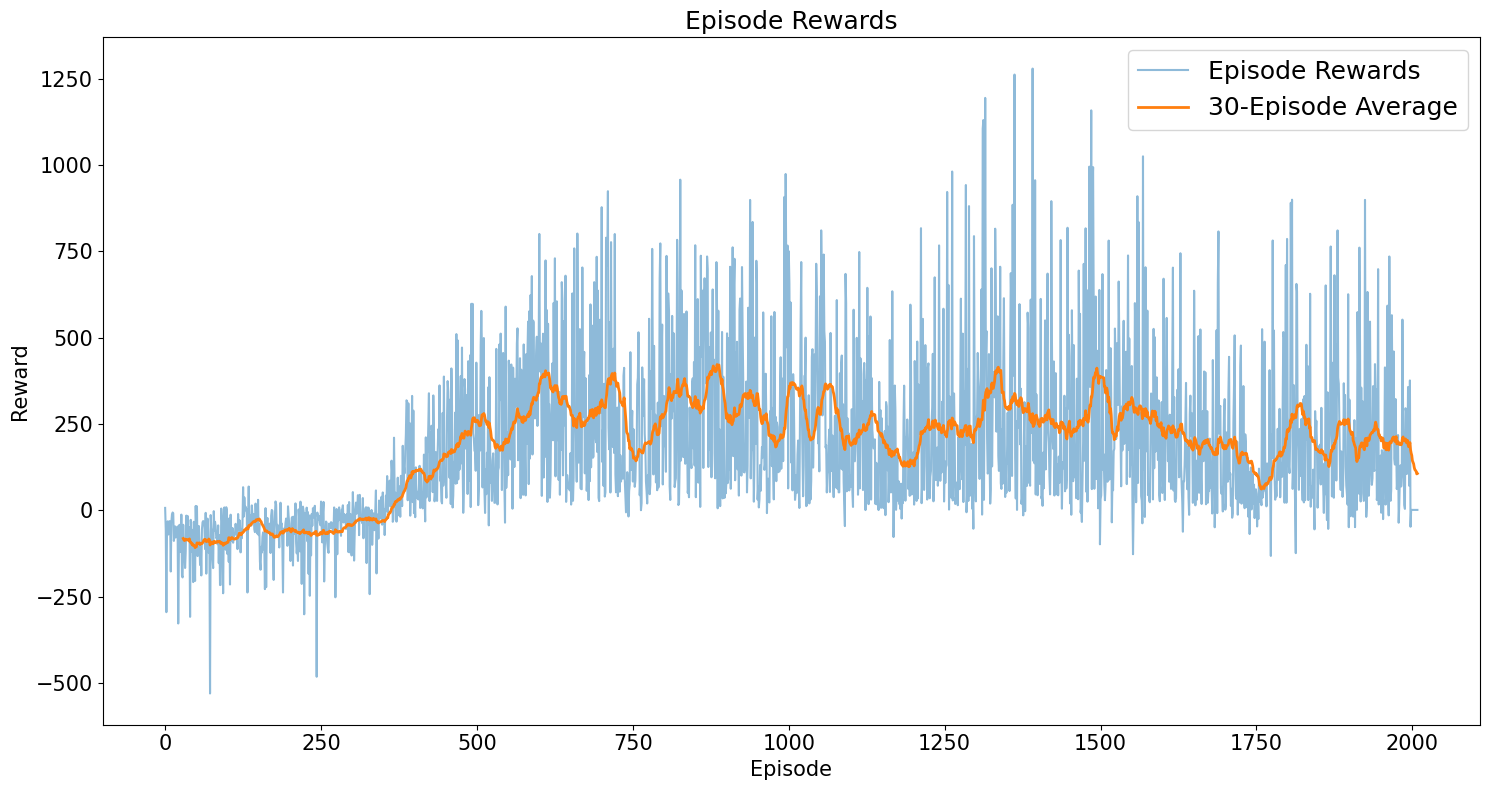

In [33]:
print(peak_return)
print(np.mean(episode_rewards[-20:]))

plt.figure(figsize=(15, 8))
plt.plot(episode_rewards, label="Episode Rewards", alpha=0.5)
WINDOW = 30
plt.plot(
    range(WINDOW - 1, len(episode_rewards)),
    moving_average(episode_rewards, WINDOW),
    label=f"{WINDOW}-Episode Average",
    linewidth=2,
)
plt.title("Episode Rewards", fontsize=18)
plt.xlabel("Episode", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
torch.save(agent, 'SACAgent\\sac_per_ere_bestest_2000.pt2')

with open("bestest_rewards.json", 'w') as f:
    json.dump(episode_rewards, f)

In [ ]:
agent = torch.load('SACAgent\\sac_model.pt2', weights_only=False)

env = gym.make("Ant-v5", render_mode="human", healthy_z_range=(0.3, 3))
state, _ = env.reset()

rewards = 0
for _ in range(10):
    done = False
    while not done:
        env.render()
        
        state_inputs = torch.from_numpy(state).float().to(device)
        action = agent.select_action(state_inputs)

        new_state, reward, terminated, truncated, _ = env.step(action.cpu().numpy())
        rewards += reward
        done = terminated or truncated
        
        state = new_state
        
        if done:
            episode_rewards.append(episode_reward)
            state, _ = env.reset()
    print("Reward:", rewards)
    rewards = 0
        
env.close()

Reward: 84.27866467677538
Reward: 106.91311276837024
Reward: 810.7125829091224
Reward: 451.2284973962094
Reward: 301.7349938060485
Reward: 62.26834476411581
Reward: -16.159589189471692
Reward: 459.98006193702633
Reward: 27.477511259678657
Reward: 465.7780645520555
